<a href="https://colab.research.google.com/github/UlfaSaadah/Face_Emotion_CNN/blob/main/uji_coba.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sms
import pandas as pd

%matplotlib inline

In [2]:
url = "https://docs.google.com/spreadsheets/d/1jJ91fbb-y55xh9QDuX2ZgqP2RZxrftOPFkOEFdrlZKk/export?format=csv"
df = pd.read_csv(url)

df.head(365)

,Tanggal,Total (Butir)
0,01/01/2025,0
1,02/01/2025,960
2,03/01/2025,3840
3,04/01/2025,0
4,05/01/2025,2880
...,...,...
360,27/12/2025,2890
361,28/12/2025,460
362,29/12/2025,3408
363,30/12/2025,1695


In [3]:
df['Tanggal'] = pd.to_datetime(df['Tanggal'], dayfirst=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 365 entries, 0 to 364
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Tanggal        365 non-null    datetime64[ns]
 1   Total (Butir)  365 non-null    int64         
dtypes: datetime64[ns](1), int64(1)
memory usage: 5.8 KB


In [4]:
df.set_index('Tanggal', inplace=True)
df.sort_index(inplace=True)
df

,Total (Butir)
Tanggal,
2025-01-01,0
2025-01-02,960
2025-01-03,3840
2025-01-04,0
2025-01-05,2880
...,...
2025-12-27,2890
2025-12-28,460
2025-12-29,3408


<Axes: xlabel='Tanggal'>

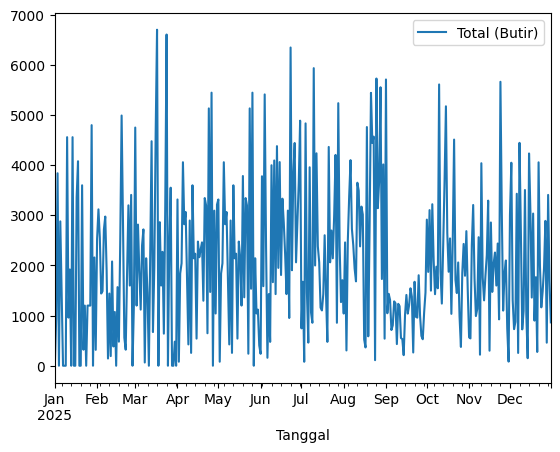

In [5]:
df.plot()

In [6]:
weekly = df.resample('W').sum()

print(weekly)

            Total (Butir)
Tanggal                  
2025-01-05           7680
2025-01-12           8880
2025-01-19          12000
2025-01-26           7520
2025-02-02          14125
2025-02-09          13232
2025-02-16           6736
2025-02-23          13584
2025-03-02          15360
2025-03-09          13136
2025-03-16          15551
2025-03-23          17200
2025-03-30          13040
2025-04-06          14165
2025-04-13          14185
2025-04-20          13496
2025-04-27          19245
2025-05-04          14633
2025-05-11          15325
2025-05-18          14361
2025-05-25          18603
2025-06-01          10397
2025-06-08          15217
2025-06-15          21587
2025-06-22          15698
2025-06-29          25079
2025-07-06          14146
2025-07-13          20437
2025-07-20          10262
2025-07-27          19348
2025-08-03          14401
2025-08-10          18731
2025-08-17          16604
2025-08-24          22713
2025-08-31          24398
2025-09-07          12312
2025-09-14  

In [7]:
data = weekly.iloc[:, 0]

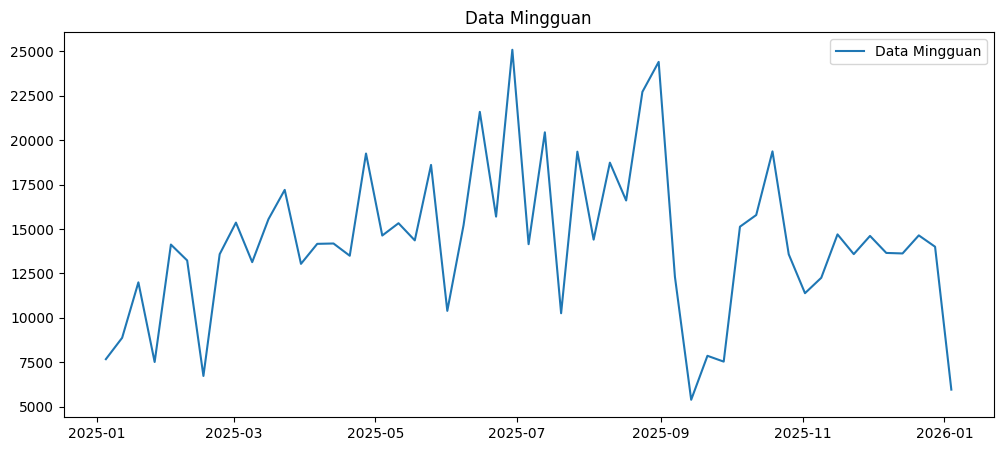

In [8]:
plt.figure(figsize=(12,5))
plt.plot(weekly, label='Data Mingguan')
plt.title('Data Mingguan')
plt.legend()
plt.show()

In [9]:
q1 = data.quantile(0.25)
q3 = data.quantile(0.75)
iqr = q3 - q1

data = data.clip(lower=q1 - 1.5*iqr, upper=q3 + 1.5*iqr)

Arima

In [10]:
from statsmodels.tsa.stattools import adfuller
result = adfuller(data)

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -3.399185685543127
p-value: 0.010986662874644004


In [11]:
if result[1] > 0.05:
    data_diff = data.diff().dropna()
else:
    data_diff = data

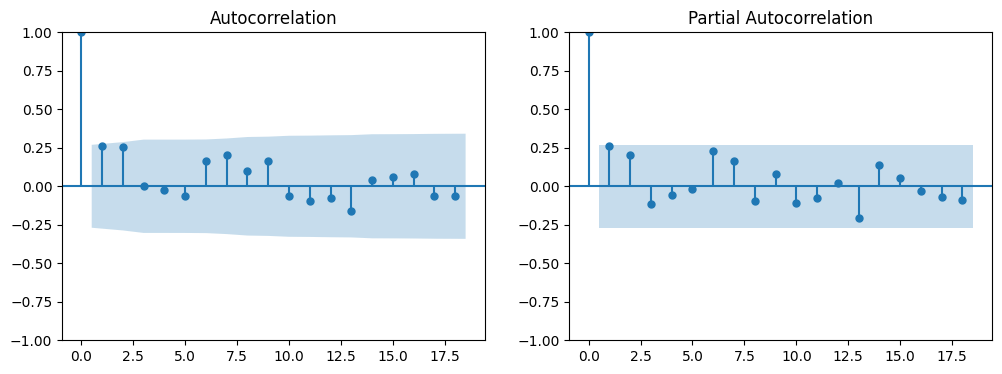

In [12]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plot_acf(data_diff, ax=plt.gca())

plt.subplot(1,2,2)
plot_pacf(data_diff, ax=plt.gca())

plt.show()

In [13]:
train = data[:-7]
test  = data[-7:]

In [14]:
from statsmodels.tsa.arima.model import ARIMA
model = ARIMA(train, order=(1,1,1))
model_fit = model.fit()

In [15]:
forecast = model_fit.forecast(steps=len(test))
forecast.index = test.index

In [16]:
future_arima = model_fit.forecast(steps=7)

print("Forecast ARIMA 7 Hari Kedepan")
for i, val in enumerate(future_arima):
    print(f"Hari ke-{i+1}: {round(val)} butir")

Forecast ARIMA 7 Hari Kedepan
Hari ke-1: 13837 butir
Hari ke-2: 13737 butir
Hari ke-3: 13726 butir
Hari ke-4: 13724 butir
Hari ke-5: 13724 butir
Hari ke-6: 13724 butir
Hari ke-7: 13724 butir


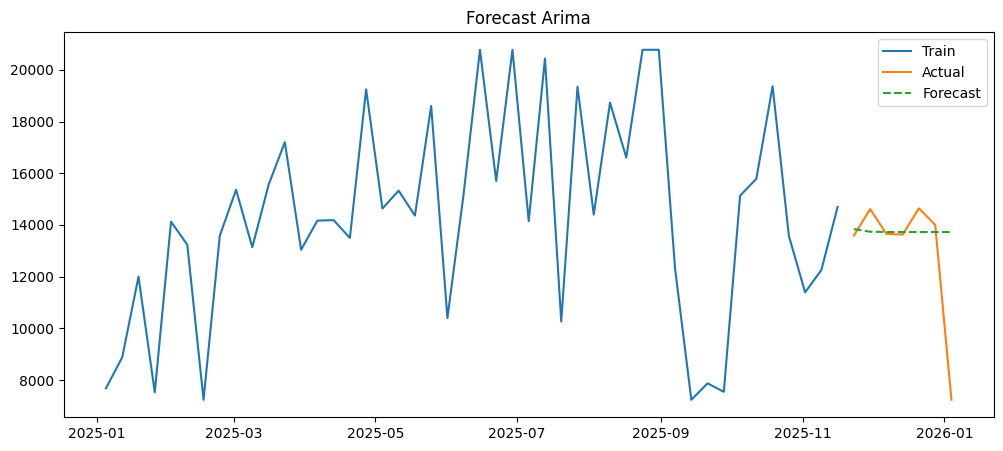

In [17]:
plt.figure(figsize=(12,5))

plt.plot(train, label='Train')
plt.plot(test, label='Actual')
plt.plot(forecast, label='Forecast', linestyle='--')

plt.title("Forecast Arima")
plt.legend()
plt.show()

In [18]:
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
mse  = mean_squared_error(test, forecast)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(test, forecast) * 100

print("ARIMA")
print("MSE :", mse)
print("RMSE:", rmse)
print("MAPE:", mape, "%")

ARIMA
MSE : 6270559.651406532
RMSE: 2504.1085542377214
MAPE: 15.29598862331245 %


CNN

In [19]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, Dense, Flatten

In [20]:
# Ambil nilai
data = weekly.values

# Normalisasi
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data)

In [21]:
def create_dataset(data, n_steps=4):
    X, y = [], []
    for i in range(len(data)-n_steps):
        X.append(data[i:i+n_steps])
        y.append(data[i+n_steps])
    return np.array(X), np.array(y)

X, y = create_dataset(data_scaled, 4)

In [22]:
split = int(len(X)*0.8)

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

In [23]:
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

In [24]:
model = Sequential([
    Conv1D(filters=64, kernel_size=2, activation='relu', input_shape=(4,1)),
    Flatten(),
    Dense(50, activation='relu'),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 3, 64)          │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 192)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 50)             │         9,650 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,893 (38.64 KB)

 Trainable params: 9,893 (38.64 KB)

 Non-trainable params: 0 (0.00 B)

In [25]:
history = model.fit(X_train, y_train,
                    epochs=50,
                    verbose=1,
                    validation_data=(X_test, y_test))

Epoch 1/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 214ms/step - loss: 0.2517 - val_loss: 0.0750
Epoch 2/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - loss: 0.1761 - val_loss: 0.0422
Epoch 3/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - loss: 0.1198 - val_loss: 0.0243
Epoch 4/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - loss: 0.0872 - val_loss: 0.0197
Epoch 5/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - loss: 0.0688 - val_loss: 0.0239
Epoch 6/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - loss: 0.0602 - val_loss: 0.0322
Epoch 7/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - loss: 0.0640 - val_loss: 0.0406
Epoch 8/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - loss: 0.0681 - val_loss: 0.0426
Epoch 9/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - loss: 0.0680 - val_loss: 0.0392
Epoch 10/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - loss: 0.0651 - val_loss: 0.0349
Epoch 11/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - loss: 0.0610 - val_loss: 0.0300
Epoch 12/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - loss: 0.0586 - val_loss: 0.0251


In [26]:
y_pred = model.predict(X_test)

# Balikin ke skala asli
y_test_inv = scaler.inverse_transform(y_test)
y_pred_inv = scaler.inverse_transform(y_pred)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step


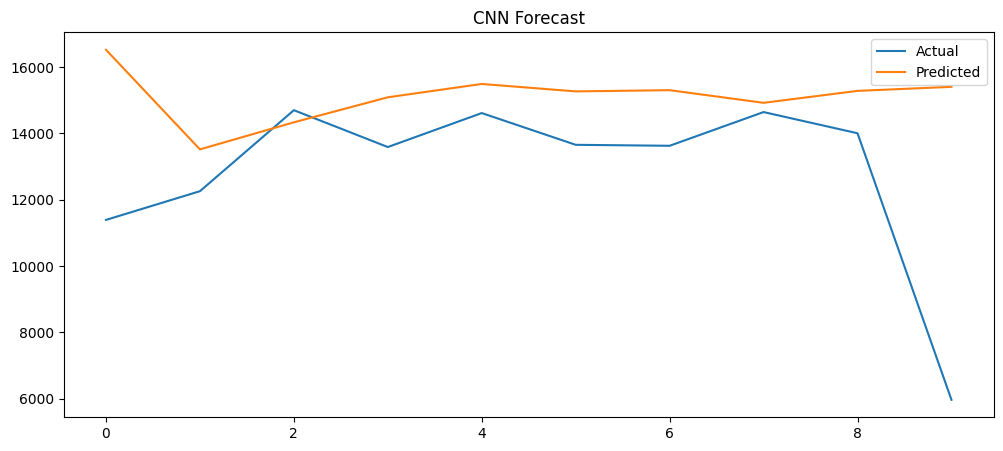

In [27]:
plt.figure(figsize=(12,5))
plt.plot(y_test_inv, label='Actual')
plt.plot(y_pred_inv, label='Predicted')
plt.title('CNN Forecast')
plt.legend()
plt.show()

In [28]:
mse = mean_squared_error(y_test_inv, y_pred_inv)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(y_test_inv, y_pred_inv) * 100

print("MSE :", mse)
print("RMSE:", rmse)
print("MAPE:", mape, "%")

MSE : 12715510.956464196
RMSE: 3565.881511837458
MAPE: 26.803784118594624 %


LSTM

In [29]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

In [30]:
data = weekly.values

# Normalisasi
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data)

In [31]:
def create_dataset(data, n_steps=8):
    X, y = [], []
    for i in range(len(data)-n_steps):
        X.append(data[i:i+n_steps])
        y.append(data[i+n_steps])
    return np.array(X), np.array(y)

X, y = create_dataset(data_scaled, 8)

In [32]:
split = int(len(X)*0.8)

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

In [33]:
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

In [34]:
model = Sequential([
    LSTM(64, activation='relu', return_sequences=False, input_shape=(8,1)),
    Dense(50, activation='relu'),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 50)             │         3,250 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,197 (78.89 KB)

 Trainable params: 20,197 (78.89 KB)

 Non-trainable params: 0 (0.00 B)

In [35]:
history = model.fit(X_train, y_train,
                    epochs=100,
                    verbose=1,
                    validation_data=(X_test, y_test))

Epoch 1/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 558ms/step - loss: 0.2861 - val_loss: 0.1274
Epoch 2/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - loss: 0.2473 - val_loss: 0.1029
Epoch 3/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - loss: 0.2115 - val_loss: 0.0817
Epoch 4/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - loss: 0.1797 - val_loss: 0.0638
Epoch 5/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - loss: 0.1503 - val_loss: 0.0480
Epoch 6/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step - loss: 0.1237 - val_loss: 0.0343
Epoch 7/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step - loss: 0.0996 - val_loss: 0.0239
Epoch 8/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step - loss: 0.0790 - val_loss: 0.0183
Epoch 9/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step - loss: 0.0615 - val_loss: 0.0186
Epoch 10/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step - loss: 0.0527 - val_loss: 0.0262
Epoch 11/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - loss: 0.0532 - val_loss: 0.0384
Epoch 12/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - loss: 0.059

In [36]:
y_pred = model.predict(X_test)

# balik ke skala asli
y_test_inv = scaler.inverse_transform(y_test)
y_pred_inv = scaler.inverse_transform(y_pred)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 421ms/step


In [37]:
last_data = data_scaled[-8:]
last_data = last_data.reshape((1,8,1))

future = model.predict(last_data)
future = scaler.inverse_transform(future)

print("Forecast minggu depan:", future)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step
Forecast minggu depan: [[14515.23]]


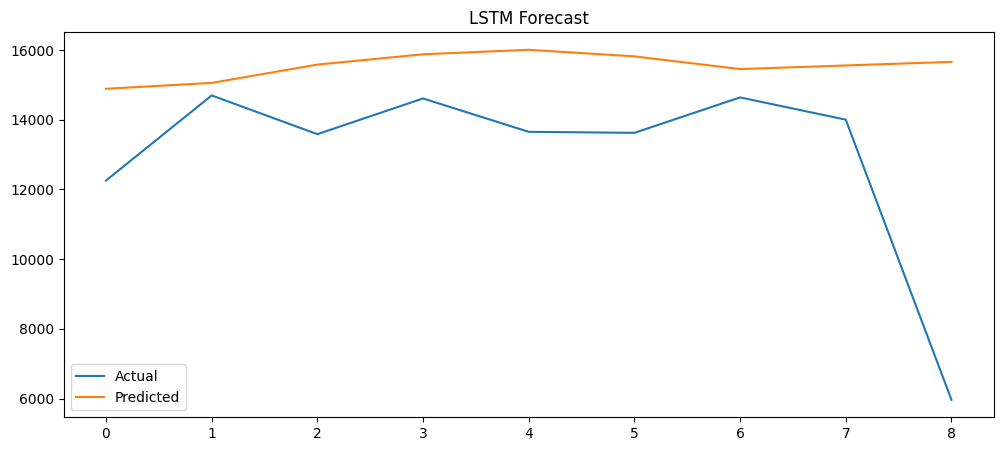

In [38]:
plt.figure(figsize=(12,5))
plt.plot(y_test_inv, label='Actual')
plt.plot(y_pred_inv, label='Predicted')
plt.title('LSTM Forecast')
plt.legend()
plt.show()

In [39]:
mse = mean_squared_error(y_test_inv, y_pred_inv)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(y_test_inv, y_pred_inv) * 100

print("MSE :", mse)
print("RMSE:", rmse)
print("MAPE:", mape, "%")

MSE : 13335881.928968748
RMSE: 3651.8326808561133
MAPE: 28.85380123746742 %
